# MVP — Machine Learning & Analytics

**Nome:** _Filipe Ferreira Calvario_  
**Matrícula:** _4052026000837_  
**Data:** _07/06/2026_  
**Dataset:** _BTCUSDT daily klines - Binance Public Data_ https://raw.githubusercontent.com/calvariofilipe/PUC/main/btc_binance_ml_dataset.csv
em: https://github.com/calvariofilipe/PUC   
**Tipo de problema:** _Classificação_  

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✓ |
| Dataset descrito, com fonte, atributos e restrições | ✓ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✓ |
| Análise exploratória objetiva, conectada à modelagem | ✓ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✓ |
| Prevenção de vazamento de dados | ✓ |
| Tratamentos de dados justificados | ✓ |
| Pipeline ou sequência reprodutível de pré-processamento | ✓ |
| Modelo baseline definido | ✓ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✓ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✓ |
| Avaliação com métricas coerentes com o problema | ✓ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✓ |
| Código limpo, organizado e executável do início ao fim | ✓ |
| Conclusão conectada ao objetivo inicial | ✓ |

# 1. Definição do problema

## 1.1 Descrição do problema

Este MVP tem como tema a previsão de períodos futuros de alta volatilidade do Bitcoin utilizando técnicas de Machine Learning.

A escolha do tema está relacionada à minha experiência profissional com o [LiveCoinWatch](https://www.livecoinwatch.com/), uma plataforma voltada ao acompanhamento de preços, volumes, liquidez e outras informações de mercado sobre criptoativos. No meu trabalho, tenho contato com dados e análises ligadas ao ecossistema cripto, incluindo coleta, organização e visualização de informações de mercado. Essa experiência motivou a escolha de um problema que conectasse os conteúdos da disciplina com um contexto profissional real.

O mercado de criptomoedas é caracterizado por oscilações intensas de preço. No caso do Bitcoin, períodos de alta volatilidade podem afetar análises de risco, visualizações de mercado e interpretação do comportamento do ativo. No entanto, este projeto não tem como objetivo prever se o preço do Bitcoin irá subir ou cair, nem gerar recomendação de investimento. O foco é investigar se dados históricos de mercado podem ajudar a identificar, com antecedência, períodos em que o ativo tende a apresentar maior instabilidade.

Para garantir reprodutibilidade acadêmica, este projeto não utiliza dados internos, privados ou comerciais do LiveCoinWatch. A base utilizada é pública e foi construída a partir de dados históricos diários do par BTCUSDT, obtidos da Binance Public Data.

O problema foi formulado como uma tarefa de **classificação** binária supervisionada. A variável-alvo indica se os 30 dias seguintes a uma determinada data foram classificados como período de alta volatilidade. Assim, cada linha da base representa uma data de referência, com variáveis explicativas calculadas a partir de informações históricas disponíveis até aquele momento.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever períodos futuros de alta volatilidade do Bitcoin a partir de dados históricos de mercado, como preço, volume, número de negociações, retornos passados, médias móveis e volatilidade histórica. Para isso, será comparada uma abordagem baseline com modelos candidatos de classificação, discutindo seus resultados e limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação_

**Justificativa:** _O modelo foi treinado com exemplos previamente rotulados e a variável-alvo possui duas classes possíveis: 0, indicando ausência de alta volatilidade futura, e 1, indicando presença de alta volatilidade futura._

_Cabe destacar que, por se tratar de dados organizados cronologicamente, a separação entre treino e teste respeitou a ordem temporal da série. Assim, o modelo foi treinado com dados anteriores e avaliado em dados posteriores, reduzindo o risco de vazamento de informações futuras._

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Hipótese 1:  _Variáveis históricas de mercado, como retornos passados, volatilidade recente, volume negociado, número de negociações, médias móveis e amplitude diária, podem conter algum sinal relacionado à volatilidade futura do Bitcoin._
2. Hipótese 2: _Modelos de Machine Learning podem apresentar desempenho superior ao baseline na identificação de períodos futuros de alta volatilidade, especialmente quando avaliados por métricas voltadas à classe positiva._
3. Hipótese 3: <em>Apesar da dificuldade de prever comportamentos futuros em mercados financeiros, modelos baseados em árvores, como</em> Random Forest<em>, podem capturar relações não lineares entre os indicadores históricos e a ocorrência de alta volatilidade futura.</em>

**Critérios de sucesso:**
- Métrica principal: _F1-score da classe positiva (high_future_volatility = 1), pois o objetivo principal é identificar períodos futuros de alta volatilidade, e não apenas maximizar a acurácia geral._
- Resultado mínimo esperado: _o modelo final deve superar o baseline em F1-score para a classe positiva. Como o baseline tende a prever apenas a classe majoritária, espera-se que o modelo escolhido consiga identificar pelo menos parte dos casos de alta volatilidade._
- Restrição prática: _o modelo deve ser simples o suficiente para ser interpretável em um MVP acadêmico, ter tempo de treino baixo e utilizar apenas dados públicos e reproduzíveis, sem depender de APIs privadas, credenciais ou dados internos._

# 2. Ambiente, bibliotecas e reprodutibilidade

O projeto utiliza bibliotecas de manipulação de dados, visualização e Machine Learning, como `pandas`, `numpy`, `matplotlib` e `scikit-learn`. Como os modelos utilizados são relativamente leves, não há necessidade de GPU; a execução pode ser feita em CPU.

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Modelos de Machine Learning
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Pré-processamento e pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Métricas de avaliação
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	roc_auc_score,
	classification_report,
	confusion_matrix,
	ConfusionMatrixDisplay
)

# Bibliotecas para registrar versões e informações do ambiente
import sklearn
import platform

# Biblioteca para salvar e carregar modelos treinados em arquivo
import joblib

# Reprodutibilidade
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Versões das principais bibliotecas:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Informações do ambiente:")
print("Python:", platform.python_version())
print("Sistema operacional:", platform.system(), platform.release())


Versões das principais bibliotecas:
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
Informações do ambiente:
Python: 3.12.13
Sistema operacional: Linux 6.6.122+


A seed `RANDOM_STATE = 42` foi utilizada nos modelos que envolvem aleatoriedade, como Árvore de Decisão e Random Forest. Isso ajuda a tornar os resultados mais reproduzíveis em diferentes execuções do notebook.

## 2.1 Dependências adicionais

Não foi necessário instalar bibliotecas extras.


## 2.2 Funções auxiliares

Esta seção reúne funções reutilizáveis para análise da base, avaliação dos modelos, teste de limiares e comparação dos resultados.


In [3]:
# Resume a estrutura geral da base, incluindo tamanho, período, valores ausentes e distribuição da variável-alvo.
def resumir_base(df):
	print("Linhas:", df.shape[0])
	print("Colunas:", df.shape[1])
	print("Data inicial:", df["date"].min())
	print("Data final:", df["date"].max())

	print("\nValores ausentes:")
	print(df.isna().sum())

	print("\nDistribuição da variável-alvo:")
	print(df["high_future_volatility"].value_counts().sort_index())

	print("\nProporção da variável-alvo:")
	print(df["high_future_volatility"].value_counts(normalize=True).sort_index())


# Treina um modelo, gera previsões no conjunto de teste e calcula as principais métricas de classificação.
def avaliar_modelo(nome, modelo, X_train, y_train, X_test, y_test):
	modelo.fit(X_train, y_train)

	y_pred = modelo.predict(X_test)

	if hasattr(modelo, "predict_proba"):
		y_score = modelo.predict_proba(X_test)[:, 1]
	else:
		y_score = modelo.decision_function(X_test)

	resultado = {
		"modelo": nome,
		"accuracy": accuracy_score(y_test, y_pred),
		"precision": precision_score(y_test, y_pred, zero_division=0),
		"recall": recall_score(y_test, y_pred, zero_division=0),
		"f1": f1_score(y_test, y_pred, zero_division=0),
		"roc_auc": roc_auc_score(y_test, y_score)
	}

	print("\n" + "=" * 60)
	print(nome)
	print("=" * 60)
	print(classification_report(y_test, y_pred, zero_division=0))

	return resultado, modelo, y_pred


# Gera a matriz de confusão para visualizar acertos e erros do modelo em cada classe.
def gerar_matriz_confusao(y_test, y_pred, titulo):
	cm = confusion_matrix(y_test, y_pred)

	disp = ConfusionMatrixDisplay(
		confusion_matrix=cm,
		display_labels=["Não alta volatilidade", "Alta volatilidade"]
	)

	disp.plot(values_format="d")
	plt.title(titulo)
	plt.show()


# Testa diferentes limiares de probabilidade para transformar probabilidades previstas em classes 0 ou 1.
def testar_limiares(probabilidades, y_test, limiares):
	resultados = []

	for limiar in limiares:
		y_pred = (probabilidades >= limiar).astype(int)

		resultados.append({
			"limiar": limiar,
			"accuracy": accuracy_score(y_test, y_pred),
			"precision": precision_score(y_test, y_pred, zero_division=0),
			"recall": recall_score(y_test, y_pred, zero_division=0),
			"f1": f1_score(y_test, y_pred, zero_division=0)
		})

	return pd.DataFrame(resultados)


# Gera um gráfico de barras para comparar os modelos segundo uma métrica escolhida.
def gerar_comparacao_modelos(resultados_df, metrica):
	plt.figure(figsize=(10, 5))
	plt.bar(resultados_df["modelo"], resultados_df[metrica])
	plt.title(f"Comparação dos modelos por {metrica}")
	plt.xlabel("Modelo")
	plt.ylabel(metrica)
	plt.xticks(rotation=45)
	plt.grid(axis="y")
	plt.show()

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O arquivo utilizado diretamente neste notebook é um CSV processado, disponível publicamente no GitHub e carregado por URL pública:

https://raw.githubusercontent.com/calvariofilipe/PUC/main/btc_binance_ml_dataset.csv

Esse CSV foi construído a partir dos dados públicos de candles diários do par BTCUSDT, disponíveis na Binance Public Data. A fonte original dos dados é o repositório público de dados históricos da Binance, acessível pelo link:

https://data.binance.vision/?prefix=data/spot/monthly/klines/BTCUSDT/1d/

Também foi consultada a documentação pública do projeto:

https://github.com/binance/binance-public-data

O dataset foi escolhido porque contém informações históricas diárias do Bitcoin negociado contra USDT, incluindo preço de abertura, máxima, mínima, fechamento, volume, volume em USDT e número de negociações. Essas variáveis são adequadas para a construção de indicadores de mercado, como retornos passados, volatilidade histórica, médias móveis, variações de volume e amplitude diária.

A base utilizada é pública, reproduzível e diferente das bases usadas nas aulas da disciplina. Além disso, não contém dados pessoais, informações de usuários ou dados internos de empresas.

## 3.2 Carga dos dados

In [4]:
# === Carga dos dados ===
# Dataset: BTCUSDT daily klines - Binance Public Data
# Base processada com variáveis históricas de mercado e variável-alvo de alta volatilidade futura.

url = "https://raw.githubusercontent.com/calvariofilipe/PUC/main/btc_binance_ml_dataset.csv"

df = pd.read_csv(url)
df["date"] = pd.to_datetime(df["date"])

df.head()


,date,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,...,ma_7d,ma_30d,ma_90d,ma_365d,distance_ma_7d,distance_ma_30d,distance_ma_90d,distance_ma_365d,future_volatility_30d,high_future_volatility
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,23741.687033,8.814925e+07,154227,12919.155899,4.797344e+07,...,3740.311429,3640.871333,5160.729333,7511.859534,0.015194,0.042921,-0.264224,-0.494514,0.026083,0
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369,1.338766e+08,218538,17921.600114,6.827790e+07,...,3751.857143,3640.023000,5130.337889,7482.225151,0.028440,0.060037,-0.247894,-0.484303,0.025920,0
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359,1.116574e+08,199812,14793.083267,5.617250e+07,...,3780.267143,3633.861000,5098.461556,7451.669726,-0.003568,0.036578,-0.261193,-0.494505,0.025773,0
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671,1.110346e+08,192232,15579.303258,5.861620e+07,...,3773.517143,3634.600000,5067.325333,7420.799781,0.004901,0.043309,-0.251674,-0.489003,0.025797,0
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751,1.158935e+08,203673,14908.914175,5.666746e+07,...,3784.322857,3643.340333,5035.722000,7384.664356,-0.003531,0.035028,-0.251158,-0.489353,0.025802,0


## 3.3 Visão geral do dataset

Antes da etapa de modelagem, foi realizada uma análise inicial da base para verificar sua estrutura, dimensão, tipos de dados, valores ausentes, duplicatas e variáveis que não devem ser utilizadas diretamente como entrada do modelo.

A base possui uma coluna de data (date), utilizada para organizar a série temporal e realizar a separação cronológica entre treino e teste. A variável-alvo é high_future_volatility, que indica se os 30 dias seguintes foram classificados como período de alta volatilidade. A coluna future_volatility_30d foi mantida para auditoria da construção do alvo, mas não deve ser usada como variável explicativa, pois contém informação futura.


In [5]:
# Dimensões da base
print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

# Período coberto pela base
print("Data inicial:", df["date"].min())
print("Data final:", df["date"].max())

# Tipos dos atributos
df.info()
# Valores ausentes por coluna
valores_ausentes = df.isna().sum()

valores_ausentes[valores_ausentes > 0]

# Verificação geral de valores ausentes
print("Total de valores ausentes:", df.isna().sum().sum())
# Verificação de duplicatas
print("Linhas duplicadas:", df.duplicated().sum())
print("Datas duplicadas:", df["date"].duplicated().sum())
# Descrição da variável-alvo
target_counts = df["high_future_volatility"].value_counts().sort_index()
target_proportions = df["high_future_volatility"].value_counts(normalize=True).sort_index()

print("Distribuição absoluta do target:")
print(target_counts)
print("\nDistribuição proporcional do target:")
print(target_proportions)

# Colunas que não devem entrar diretamente no modelo
colunas_removidas_modelagem = [
	"date",
	"future_volatility_30d",
	"high_future_volatility"
]
print("Colunas removidas da matriz de atributos:")
print(colunas_removidas_modelagem)

Quantidade de linhas: 2527
Quantidade de colunas: 48
Data inicial: 2019-01-01 00:00:00
Data final: 2025-12-01 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          2527 non-null   datetime64[ns]
 1   open                          2527 non-null   float64       
 2   high                          2527 non-null   float64       
 3   low                           2527 non-null   float64       
 4   close                         2527 non-null   float64       
 5   volume                        2527 non-null   float64       
 6   quote_asset_volume            2527 non-null   float64       
 7   number_of_trades              2527 non-null   int64         
 8   taker_buy_base_asset_volume   2527 non-null   float64       
 9   taker_buy_quote_asset_volume  2527 non-null

A base final contém 2527 registros e 48 colunas, cobrindo o período de 2019-01-01 a 2025-12-01. Não foram identificados valores ausentes ou duplicatas na versão final do dataset.

A coluna `date` será usada apenas para ordenação temporal e separação entre treino e teste. A coluna `high_future_volatility` é a variável-alvo do problema. A coluna `future_volatility_30d`, embora esteja presente na base, não será utilizada como variável explicativa, pois representa informação futura e poderia causar vazamento de dados.

A distribuição da variável-alvo indica que a classe positiva é menos frequente que a classe negativa, o que torna necessário avaliar os modelos com métricas além da acurácia, como precision, recall e F1-score.


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `date` | data | Data de referência de cada observação diária | não | Usada apenas para ordenação temporal e separação treino/teste |
| `open` | numérica | Preço de abertura do Bitcoin no dia | sim | Variável original do candle diário |
| `high` | numérica | Maior preço do Bitcoin no dia | sim | Variável original do candle diário |
| `low` | numérica | Menor preço do Bitcoin no dia | sim | Variável original do candle diário |
| `close` | numérica | Preço de fechamento do Bitcoin no dia. | sim | Usada como principal referência para retornos e volatilidade |
| `volume` | numérica | Volume negociado de Bitcoin no dia | sim | Indicador de atividade de mercado |
| `quote_asset_volume` | numérica | Volume negociado em USDT no dia | sim | Mede o volume financeiro negociado |
| `number_of_trades` | numérica | Número de negociações realizadas no dia | sim | Representa intensidade de atividade no mercado |
| `taker_buy_base_asset_volume` | numérica | Volume de compra agressora em BTC | sim | Indicador relacionado à pressão compradora |
| `taker_buy_quote_asset_volume` | numérica | Volume de compra agressora em USDT | sim | Indicador relacionado à pressão compradora em valor financeiro |
| `return_1d`, `return_7d`, `return_30d`, `return_90d`, `return_365d` | numérica | Retornos passados em diferentes janelas temporais | sim | Criadas a partir do preço de fechamento |
| `volatility_7d`, `volatility_30d`, `volatility_90d`, `volatility_365d` | numérica | Volatilidade histórica calculada a partir dos retornos diários | sim | Representam o comportamento passado da volatilidade |
| `volume_mean_7d`, `volume_mean_30d`, `volume_mean_90d` | numérica | Médias móveis do volume negociado | sim | Criadas para capturar tendências recentes de volume |
| `volume_change_7d`, `volume_change_30d` | numérica | Variações relativas do volume médio em diferentes janelas | sim | Indicam aumento ou redução recente da atividade de negociação |
| `quote_volume_mean_7d`, `quote_volume_mean_30d`, `quote_volume_mean_90d` | numérica | Médias móveis do volume financeiro em USDT | sim | Representam o volume negociado em valor financeiro |
| `quote_volume_change_7d`, `quote_volume_change_30d` | numérica | Variações relativas do volume financeiro médio | sim | Indicadores de mudança na intensidade financeira do mercado |
| `trades_mean_7d`, `trades_mean_30d`, `trades_mean_90d` | numérica | Médias móveis do número de negociações | sim | Capturam variações na frequência de negociações |
| `trades_change_7d`, `trades_change_30d` | numérica | Variações relativas do número médio de negociações | sim | Indicadores de aceleração ou desaceleração da atividade de mercado |
| `hl_range`, `hl_range_7d`, `hl_range_30d`, `hl_range_90d` | numérica | Amplitude entre máxima e mínima do dia, em forma relativa | sim | Medem a oscilação intradiária e suas médias recentes |
| `ma_7d`, `ma_30d`, `ma_90d`, `ma_365d` | numérica | Médias móveis do preço de fechamento | sim | Usadas para representar tendências de curto, médio e longo prazo |
| `distance_ma_7d`, `distance_ma_30d`, `distance_ma_90d`, `distance_ma_365d` | numérica | Distância relativa entre o preço atual e suas médias móveis | sim | Indicam se o preço está acima ou abaixo de tendências recentes |
| `future_volatility_30d` | numérica | Volatilidade realizada nos 30 dias seguintes | não | Usada apenas para construir e auditar a variável-alvo; não entra no modelo por conter informação futura |
| `high_future_volatility` | alvo | Indica se os 30 dias seguintes foram classificados como alta volatilidade | alvo | `0` = não alta volatilidade futura; `1` = alta volatilidade futura |

# 4. Análise exploratória dos dados

Nesta seção serão analisadas a distribuição da variável-alvo, o comportamento do preço do Bitcoin, a volatilidade futura de 30 dias e algumas variáveis relevantes para a modelagem. O objetivo é identificar padrões, desbalanceamentos e possíveis relações entre os atributos históricos e a ocorrência de alta volatilidade futura.


Distribuição do target:


,contagem
high_future_volatility,
0,1785
1,742


Distribuição percentual do target:


,percentual
high_future_volatility,
0,70.64
1,29.36


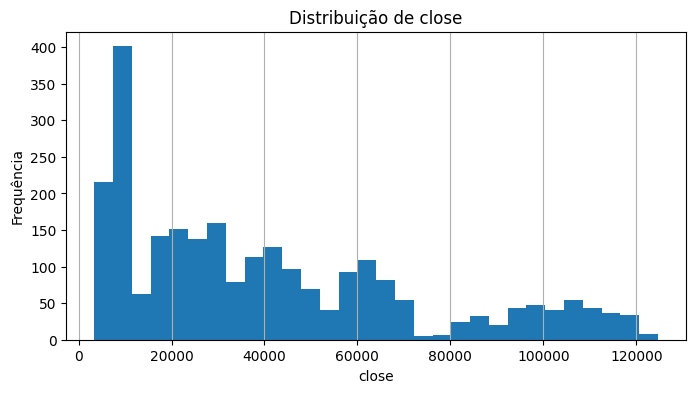

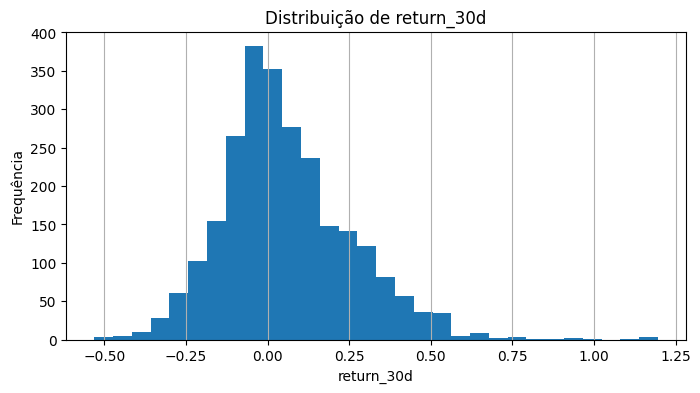

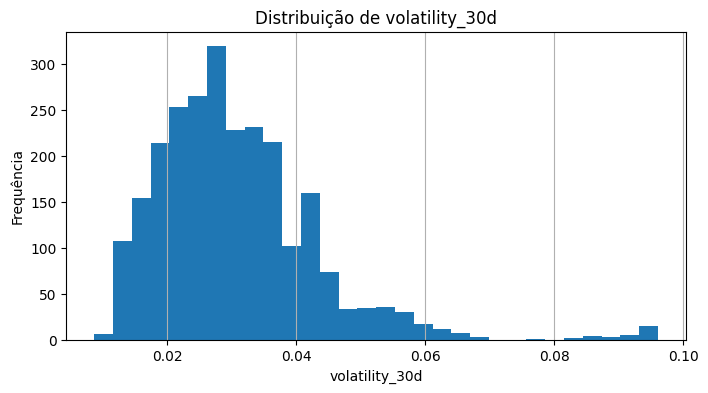

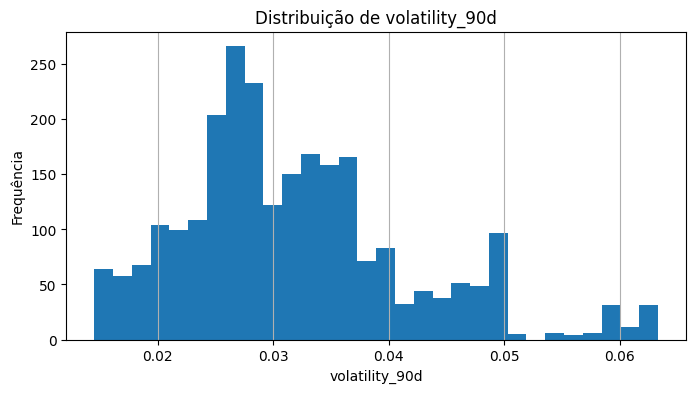

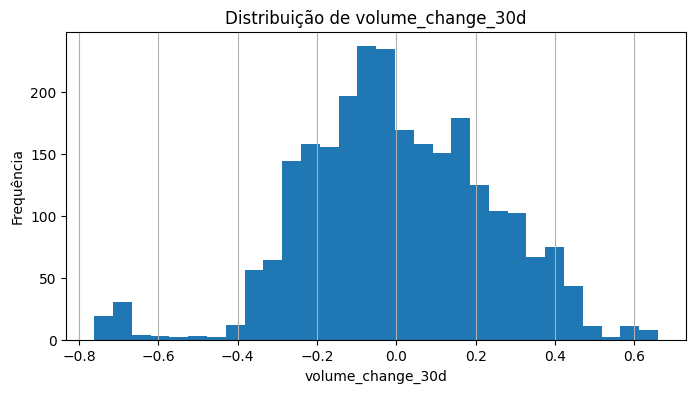

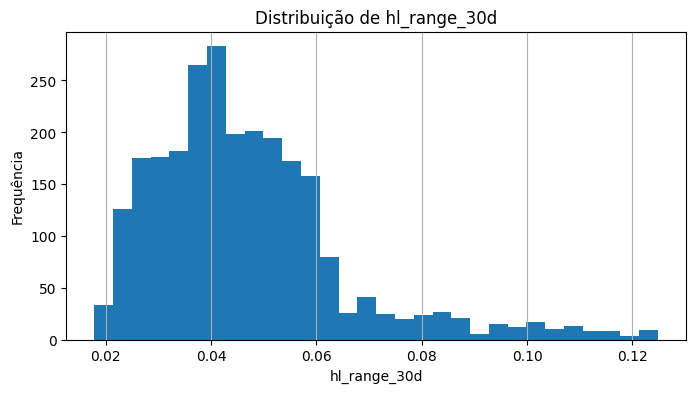

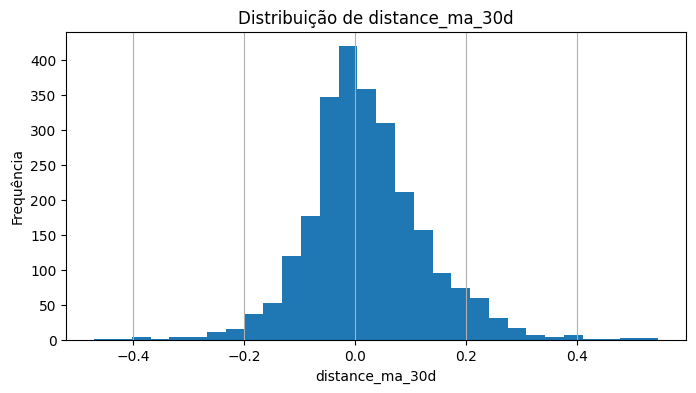

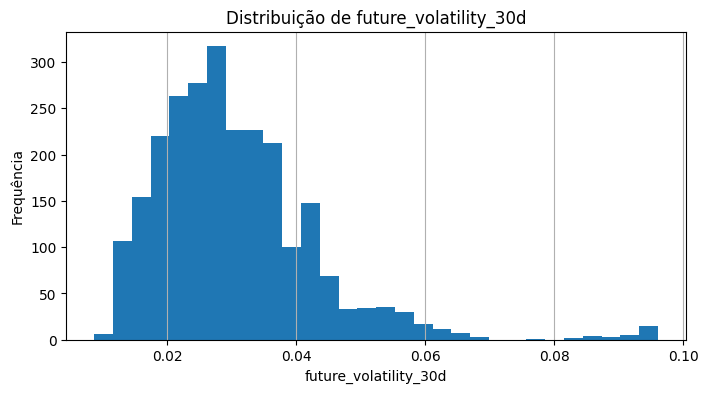

In [6]:
# Ajuste das variáveis principais do problema
TARGET = "high_future_volatility"
PROBLEM_TYPE = "classificacao"

# Distribuição da variável-alvo
print("Distribuição do target:")
display(df[TARGET].value_counts(dropna=False).sort_index().to_frame("contagem"))

print("Distribuição percentual do target:")
display((df[TARGET].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2).to_frame("percentual"))# Variáveis numéricas relevantes para a análise exploratória
variaveis_importantes = [
	"close",
	"return_30d",
	"volatility_30d",
	"volatility_90d",
	"volume_change_30d",
	"hl_range_30d",
	"distance_ma_30d",
	"future_volatility_30d"
]

for col in variaveis_importantes:
	plt.figure(figsize=(8, 4))
	df[col].hist(bins=30)
	plt.title(f"Distribuição de {col}")
	plt.xlabel(col)
	plt.ylabel("Frequência")
	plt.grid(axis="y")
	plt.show()

<Figure size 700x400 with 0 Axes>

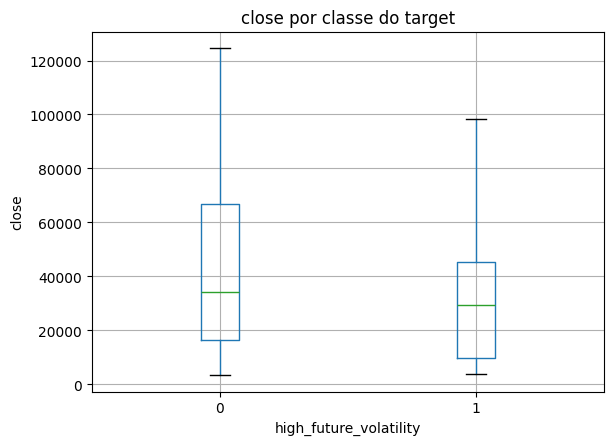

<Figure size 700x400 with 0 Axes>

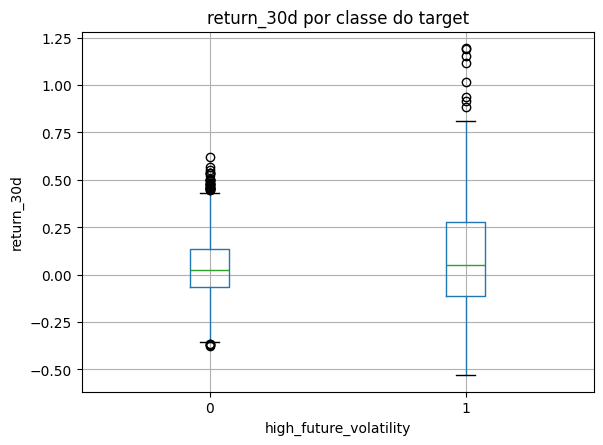

<Figure size 700x400 with 0 Axes>

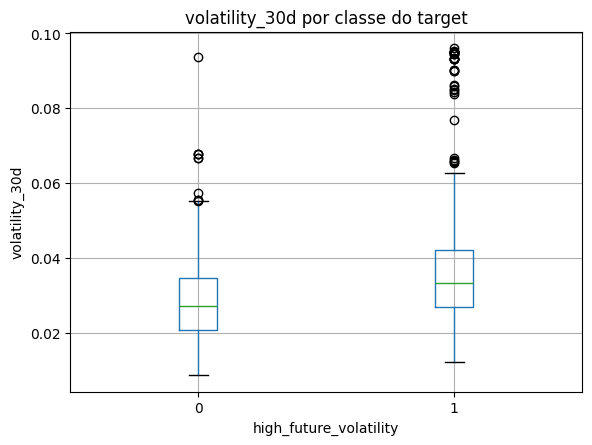

<Figure size 700x400 with 0 Axes>

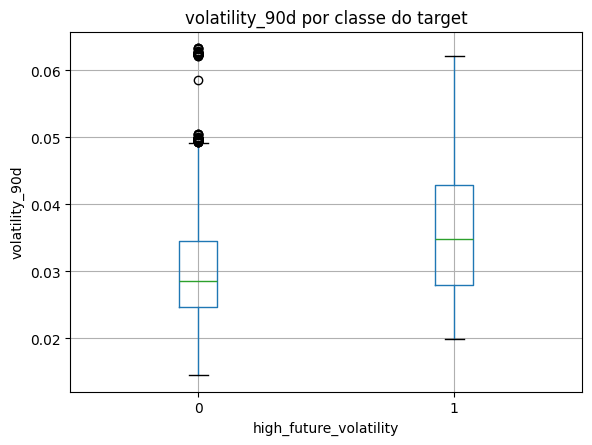

<Figure size 700x400 with 0 Axes>

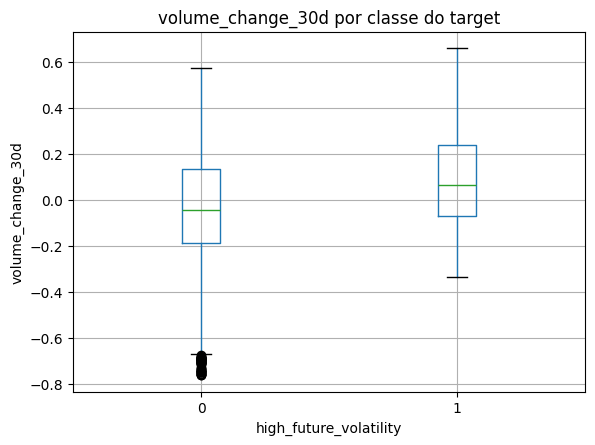

<Figure size 700x400 with 0 Axes>

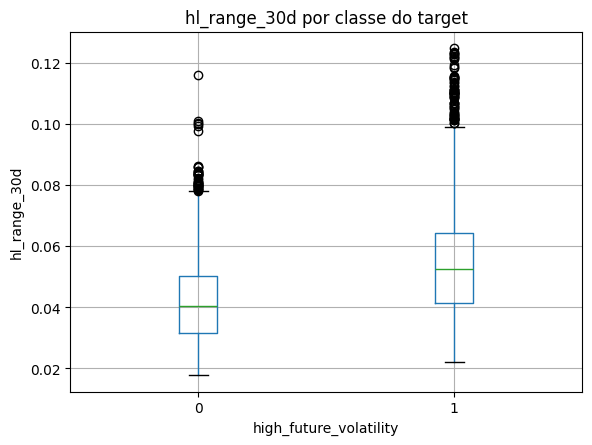

<Figure size 700x400 with 0 Axes>

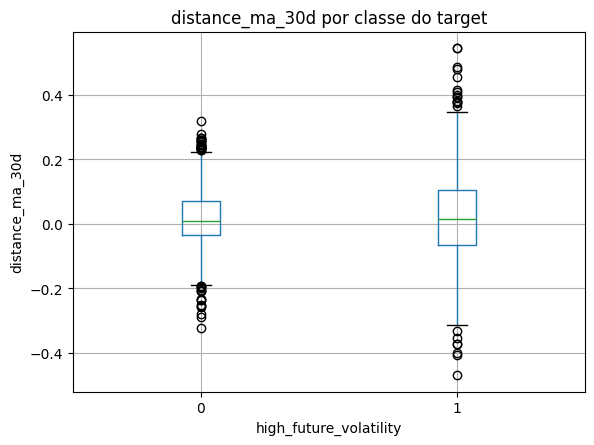

In [7]:
# Relação entre variáveis importantes e a variável-alvo
for col in variaveis_importantes:
	if col != "future_volatility_30d":
		plt.figure(figsize=(7, 4))
		df.boxplot(column=col, by=TARGET)
		plt.title(f"{col} por classe do target")
		plt.suptitle("")
		plt.xlabel(TARGET)
		plt.ylabel(col)
		plt.grid(True)
		plt.show()

## 4.1 Síntese da análise exploratória

**Síntese:**  

> _A análise exploratória mostrou que a variável-alvo apresenta desbalanceamento: a classe `0`, referente a períodos que não foram classificados como alta volatilidade futura, é mais frequente que a classe `1`. Isso indica que a acurácia, sozinha, pode ser uma métrica enganosa, pois um modelo que prevê majoritariamente a classe mais comum pode parecer bom sem identificar adequadamente os períodos de alta volatilidade._

> _Não foram identificados valores ausentes relevantes na base final. Também não foram observadas duplicatas, e a coluna `date` será usada apenas para controle temporal e separação entre treino e teste, não como variável explicativa direta._

> _As variáveis numéricas possuem escalas bastante diferentes, especialmente entre preços, volumes, número de negociações, retornos e volatilidades. Por isso, modelos sensíveis à escala, como Regressão Logística e SVM, devem utilizar padronização. Já modelos baseados em árvores, como Decision Tree e Random Forest, tendem a lidar melhor com variáveis em escalas diferentes._

> _A análise também indicou que os dados apresentam comportamento típico de séries financeiras, com períodos de maior instabilidade e mudanças de regime ao longo do tempo. Por esse motivo, a separação entre treino e teste deve respeitar a ordem cronológica dos dados, evitando vazamento de informações futuras._

> _Por fim, as variáveis históricas parecem conter algum sinal potencialmente útil para a identificação de períodos futuros de maior volatilidade, mas a sobreposição entre as classes sugere que o problema é difícil. Essa observação reforça a necessidade de comparar os modelos com um baseline e avaliar métricas como precision, recall e F1-score, especialmente para a classe positiva._


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, foram definidas as variáveis explicativas, a variável-alvo e a estratégia de divisão entre treino e teste. Como os dados estão organizados cronologicamente, a separação foi feita por data, utilizando o período de 2019 a 2023 para treinamento e o período de 2024 a 2025 para teste. Essa escolha evita que informações futuras sejam usadas no treinamento do modelo.


In [8]:
# === Configuração do problema ===
# O problema é de classificação binária, mas a divisão dos dados respeita a ordem temporal.

TARGET = "high_future_volatility"
PROBLEM_TYPE = "classificacao"
DATE_COLUMN = "date"

# Colunas que não devem entrar no modelo
# date: usada apenas para ordenação temporal
# future_volatility_30d: contém informação futura e poderia causar vazamento de dados
DROP_COLUMNS = [
	"date",
	"future_volatility_30d"
]

assert TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Coluna temporal:", DATE_COLUMN)
print("Número de features:", len(features))
print("Features:")
print(features)


Tipo de problema: classificacao
Target: high_future_volatility
Coluna temporal: date
Número de features: 45
Features:
['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'return_1d', 'return_7d', 'return_30d', 'return_90d', 'return_365d', 'volatility_7d', 'volatility_30d', 'volatility_90d', 'volatility_365d', 'volume_mean_7d', 'volume_mean_30d', 'volume_mean_90d', 'volume_change_7d', 'volume_change_30d', 'quote_volume_mean_7d', 'quote_volume_mean_30d', 'quote_volume_mean_90d', 'quote_volume_change_7d', 'quote_volume_change_30d', 'trades_mean_7d', 'trades_mean_30d', 'trades_mean_90d', 'trades_change_7d', 'trades_change_30d', 'hl_range', 'hl_range_7d', 'hl_range_30d', 'hl_range_90d', 'ma_7d', 'ma_30d', 'ma_90d', 'ma_365d', 'distance_ma_7d', 'distance_ma_30d', 'distance_ma_90d', 'distance_ma_365d']


In [9]:
# === Divisão temporal dos dados ===
# Para evitar vazamento temporal, os dados não são embaralhados.

df_sorted = df.sort_values(DATE_COLUMN).copy()

train_cutoff = "2024-01-01"

train_df = df_sorted[df_sorted[DATE_COLUMN] < train_cutoff].copy()
test_df = df_sorted[df_sorted[DATE_COLUMN] >= train_cutoff].copy()

X_train = train_df[features].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[features].copy()
y_test = test_df[TARGET].copy()

print("Período de treino:")
print(train_df[DATE_COLUMN].min(), "até", train_df[DATE_COLUMN].max())
print("Treino:", X_train.shape)

print("\nPeríodo de teste:")
print(test_df[DATE_COLUMN].min(), "até", test_df[DATE_COLUMN].max())
print("Teste:", X_test.shape)

print("\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribuição do target no teste:")
print(y_test.value_counts(normalize=True).sort_index())


Período de treino:
2019-01-01 00:00:00 até 2023-12-31 00:00:00
Treino: (1826, 45)

Período de teste:
2024-01-01 00:00:00 até 2025-12-01 00:00:00
Teste: (701, 45)

Distribuição do target no treino:
high_future_volatility
0    0.631982
1    0.368018
Name: proportion, dtype: float64

Distribuição do target no teste:
high_future_volatility
0    0.900143
1    0.099857
Name: proportion, dtype: float64


## 5.1 Justificativa da divisão

A divisão escolhida foi uma **divisão temporal**, e não uma divisão aleatória, porque os dados representam uma série histórica diária do Bitcoin. Como o objetivo é usar informações passadas para classificar períodos futuros de alta volatilidade, o modelo deve ser treinado com dados anteriores e avaliado em dados posteriores.

Foram usados os dados de 2019 a 2023 para treino e os dados de 2024 a 2025 para teste. Essa divisão mantém uma quantidade suficiente de registros para treinamento e reserva um período posterior relevante para avaliação fora da amostra.

Não foi usada estratificação aleatória, pois embaralhar os dados quebraria a ordem temporal da série e poderia gerar vazamento de informação. A divisão temporal reduz esse risco porque impede que dados futuros sejam usados durante o treinamento. Além disso, a coluna `future_volatility_30d`, que contém informação dos 30 dias seguintes, foi removida das variáveis explicativas e usada apenas na construção da variável-alvo.


# 6. Pré-processamento e pipeline

In [10]:
# === Pré-processamento ===
# Identificação das colunas numéricas e categóricas após a remoção de date, target e future_volatility_30d.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Colunas numéricas:", len(num_cols))
print(num_cols)

print("\nColunas categóricas:", len(cat_cols))
print(cat_cols)


Colunas numéricas: 45
['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'return_1d', 'return_7d', 'return_30d', 'return_90d', 'return_365d', 'volatility_7d', 'volatility_30d', 'volatility_90d', 'volatility_365d', 'volume_mean_7d', 'volume_mean_30d', 'volume_mean_90d', 'volume_change_7d', 'volume_change_30d', 'quote_volume_mean_7d', 'quote_volume_mean_30d', 'quote_volume_mean_90d', 'quote_volume_change_7d', 'quote_volume_change_30d', 'trades_mean_7d', 'trades_mean_30d', 'trades_mean_90d', 'trades_change_7d', 'trades_change_30d', 'hl_range', 'hl_range_7d', 'hl_range_30d', 'hl_range_90d', 'ma_7d', 'ma_30d', 'ma_90d', 'ma_365d', 'distance_ma_7d', 'distance_ma_30d', 'distance_ma_90d', 'distance_ma_365d']

Colunas categóricas: 0
[]


In [11]:
# Pipeline de pré-processamento para modelos sensíveis à escala.
# A mediana é usada como estratégia de imputação por ser mais robusta a valores extremos.

numeric_pipe = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="median")),
	("scaler", StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
	("num", numeric_pipe, num_cols)
], remainder="drop")

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['open', 'high', 'low', 'close', 'volume',
                                  'quote_asset_volume', 'number_of_trades',
                                  'taker_buy_base_asset_volume',
                                  'taker_buy_quote_asset_volume', 'return_1d',
                                  'return_7d', 'return_30d', 'return_90d',
                                  'return_365d', 'volatility_7d',
                                  'volatility_30d', 'volatility_90d',
                                  'volatility_365d', 'volume_mean_7d',
                                  'volume_mean_30d', 'volume_mean_90d',
                                  'volume_change_7d', 'volume_change_30d',
                                  'quote_volume_mean_7d',
                                  'quote_volume_mean_30d',
                                  'quote_volume_mean_90d',
                                  'quote_volume_change_7d',
                                  'quote_volume_change_30d', 'trades_mean_7d',
                                  'trades_mean_30d', ...])])

## 6.1 Decisões de pré-processamento

A base final não apresentou valores ausentes, mas foi incluída uma etapa de imputação pela mediana no pipeline como medida de segurança e reprodutibilidade. A mediana foi escolhida por ser mais robusta a valores extremos, que são comuns em dados financeiros.

Todas as variáveis explicativas utilizadas no modelo são numéricas, portanto não foi necessário aplicar codificação de variáveis categóricas. Também não houve tratamento de texto ou imagem.

A padronização foi incluída porque algumas variáveis possuem escalas muito diferentes, como preço, volume, número de negociações, retornos e volatilidades. Essa etapa é importante para modelos sensíveis à escala, como Regressão Logística e SVM. Modelos baseados em árvores, como Decision Tree e Random Forest, são menos sensíveis à escala, mas a preparação padronizada facilita a comparação entre diferentes abordagens.

As colunas `date`, `future_volatility_30d` e `high_future_volatility` foram removidas da matriz de atributos. A coluna `date` foi usada apenas para ordenação temporal e divisão treino/teste; `high_future_volatility` é a variável-alvo; e `future_volatility_30d` foi removida por conter informação futura, o que causaria vazamento de dados se fosse usada como entrada do modelo.

As variáveis derivadas, como retornos passados, volatilidade histórica, médias móveis, variações de volume e amplitude diária, já estavam presentes na base processada. Elas foram construídas apenas a partir de informações históricas disponíveis até cada data de referência, portanto estariam disponíveis no momento real da previsão.


# 7. Baseline e modelos candidatos



In [12]:
# === Definição de baseline e modelos candidatos ===
# O baseline prevê sempre a classe mais frequente.
# Os modelos candidatos representam abordagens diferentes de classificação.

baseline = Pipeline(steps=[
	("preprocess", preprocess),
	("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

candidates = {
	"Logistic Regression": Pipeline(steps=[
		("preprocess", preprocess),
		("model", LogisticRegression(
			max_iter=1000,
			class_weight="balanced",
			random_state=RANDOM_STATE
		))
	]),

	"Decision Tree": Pipeline(steps=[
		("model", DecisionTreeClassifier(
			random_state=RANDOM_STATE,
			class_weight="balanced",
			max_depth=5
		))
	]),

	"Random Forest": Pipeline(steps=[
		("model", RandomForestClassifier(
			n_estimators=300,
			random_state=RANDOM_STATE,
			class_weight="balanced",
			n_jobs=-1,
			max_depth=6
		))
	]),

	"SVM": Pipeline(steps=[
		("preprocess", preprocess),
		("model", SVC(
			probability=True,
			class_weight="balanced",
			random_state=RANDOM_STATE
		))
	])
}

print("Baseline:", baseline)
print("Modelos candidatos:", list(candidates.keys()))


Baseline: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['open', 'high', 'low',
                                                   'close', 'volume',
                                                   'quote_asset_volume',
                                                   'number_of_trades',
                                                   'taker_buy_base_asset_volume',
                                                   'taker_buy_quote_asset_volume',
                                                   'return_1d', 'return_7d',
                           

## 7.1 Justificativa dos modelos

O baseline escolhido foi o `DummyClassifier` com a estratégia de prever sempre a classe mais frequente. Esse baseline é coerente porque a variável-alvo é desbalanceada; portanto, ele permite verificar se os modelos candidatos realmente conseguem identificar períodos de alta volatilidade ou se apenas reproduzem a classe majoritária.

Foram escolhidos quatro modelos candidatos: Regressão Logística, Árvore de Decisão, Random Forest e SVM. A Regressão Logística foi incluída por ser um modelo linear simples e interpretável, servindo como uma referência inicial. A Árvore de Decisão foi escolhida por permitir capturar relações não lineares de forma mais simples. O Random Forest foi incluído por combinar várias árvores de decisão, geralmente oferecendo maior robustez e melhor capacidade de generalização. O SVM foi utilizado como alternativa baseada em margem, adequada para testar uma abordagem diferente das árvores.

Como as variáveis possuem escalas muito diferentes, modelos sensíveis à escala, como Regressão Logística e SVM, foram associados a um pipeline de pré-processamento com imputação e padronização. Modelos baseados em árvores, como Árvore de Decisão e Random Forest, não dependem da padronização das variáveis.

A escolha dos modelos também considerou a simplicidade e o custo computacional. Todos os modelos são adequados ao tamanho do dataset, que possui 2527 registros e 45 variáveis explicativas, e podem ser treinados rapidamente em CPU. Além disso, os modelos permitem uma comparação clara entre baseline, modelo linear, modelo baseado em árvore, ensemble e modelo baseado em margem.


# 8. Treinamento e avaliação inicial


Dummy Classifier
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       631
           1       0.00      0.00      0.00        70

    accuracy                           0.90       701
   macro avg       0.45      0.50      0.47       701
weighted avg       0.81      0.90      0.85       701


Logistic Regression
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       631
           1       0.00      0.00      0.00        70

    accuracy                           0.90       701
   macro avg       0.45      0.50      0.47       701
weighted avg       0.81      0.90      0.85       701


Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.17      0.29       631
           1       0.12      1.00      0.21        70

    accuracy                           0.25       701
   macro avg       0.56      0.59      0.25       701
weighted avg       0

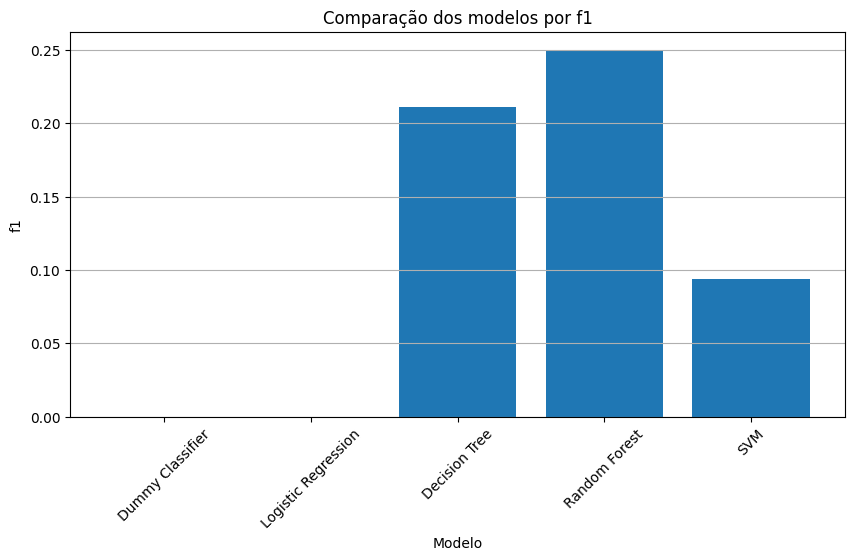

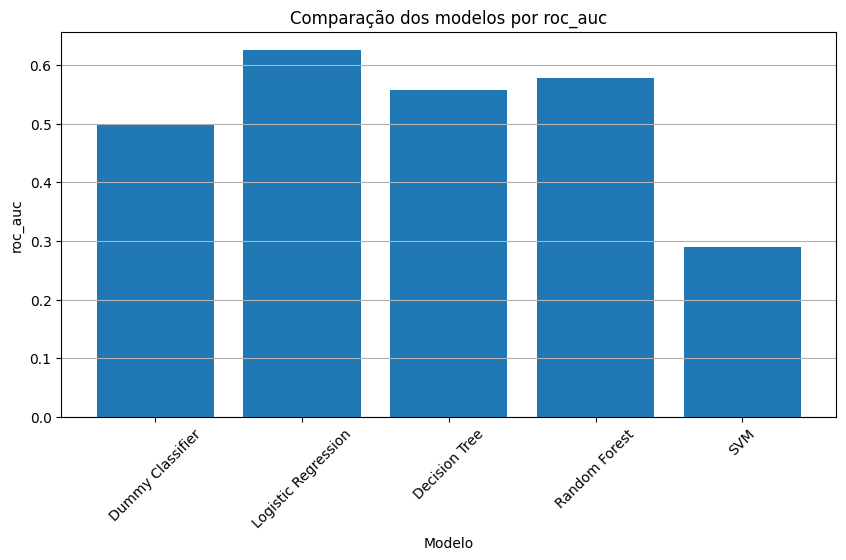

In [13]:
# === Treinamento e avaliação inicial ===
# Treina o baseline e os modelos candidatos, armazenando métricas, tempo de treino e previsões.

import time

results = []
trained_models = {}
predictions = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)

if hasattr(baseline, "predict_proba"):
	y_score = baseline.predict_proba(X_test)[:, 1]
else:
	y_score = None

baseline_result = {
	"modelo": "Dummy Classifier",
	"accuracy": accuracy_score(y_test, y_pred),
	"precision": precision_score(y_test, y_pred, zero_division=0),
	"recall": recall_score(y_test, y_pred, zero_division=0),
	"f1": f1_score(y_test, y_pred, zero_division=0),
	"roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
	"train_time_s": round(train_time, 3)
}

results.append(baseline_result)
trained_models["Dummy Classifier"] = baseline
predictions["Dummy Classifier"] = y_pred

print("\n" + "=" * 60)
print("Dummy Classifier")
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))


# Modelos candidatos
for name, model in candidates.items():
	t0 = time.time()
	model.fit(X_train, y_train)
	train_time = time.time() - t0

	y_pred = model.predict(X_test)

	if hasattr(model, "predict_proba"):
		y_score = model.predict_proba(X_test)[:, 1]
	else:
		y_score = model.decision_function(X_test)

	result = {
		"modelo": name,
		"accuracy": accuracy_score(y_test, y_pred),
		"precision": precision_score(y_test, y_pred, zero_division=0),
		"recall": recall_score(y_test, y_pred, zero_division=0),
		"f1": f1_score(y_test, y_pred, zero_division=0),
		"roc_auc": roc_auc_score(y_test, y_score),
		"train_time_s": round(train_time, 3)
	}

	results.append(result)
	trained_models[name] = model
	predictions[name] = y_pred

	print("\n" + "=" * 60)
	print(name)
	print("=" * 60)
	print(classification_report(y_test, y_pred, zero_division=0))


results_df = pd.DataFrame(results)

results_df.sort_values("f1", ascending=False)

# Comparação dos modelos por F1-score
gerar_comparacao_modelos(results_df, "f1")

# Comparação dos modelos por ROC-AUC
gerar_comparacao_modelos(results_df, "roc_auc")


## 8.1 Análise dos resultados iniciais

**Resposta:**  
Na avaliação inicial, o baseline apresentou acurácia alta, mas não identificou nenhum caso da classe positiva. Isso ocorre porque o `DummyClassifier` prevê sempre a classe majoritária, o que é problemático em uma base desbalanceada. Portanto, a acurácia isolada não é suficiente para avaliar este problema.

Entre os modelos candidatos, o Random Forest apresentou o melhor equilíbrio inicial entre precision, recall e F1-score para a classe de alta volatilidade. Embora sua acurácia tenha sido ligeiramente inferior à do baseline, ele foi mais adequado ao objetivo do MVP porque conseguiu identificar parte dos períodos de alta volatilidade, enquanto o baseline não identificou nenhum.

A Árvore de Decisão apresentou recall elevado para a classe positiva, mas com baixa precisão e baixa acurácia geral, indicando excesso de previsões positivas. Já a Regressão Logística e o SVM tiveram desempenho limitado para a classe positiva nesta configuração inicial.

O tempo de treinamento foi aceitável para todos os modelos, considerando o tamanho da base, com 2527 registros e 45 variáveis explicativas. Os resultados fazem sentido diante da análise exploratória, pois a classe positiva é minoritária e as distribuições das variáveis apresentam sobreposição entre as classes, tornando a tarefa de previsão mais difícil.


# 9. Validação e otimização de hiperparâmetros

Nesta etapa, foi feita uma busca simples de hiperparâmetros para o modelo Random Forest. A escolha desse modelo se justifica porque ele apresentou o melhor desempenho inicial em F1-score entre os modelos candidatos.

Como os dados possuem ordem temporal, foi utilizada validação com `TimeSeriesSplit`, que preserva a estrutura cronológica dos dados durante a validação. A métrica usada para guiar a escolha foi o `f1-score`, pois o objetivo principal é identificar a classe positiva, isto é, períodos futuros de alta volatilidade.


In [14]:
# === Otimização simples de hiperparâmetros ===
# Busca pequena para o modelo Random Forest, usando validação temporal e F1-score.

rf_base = RandomForestClassifier(
	random_state=RANDOM_STATE,
	class_weight="balanced",
	n_jobs=-1
)

param_grid = {
	"n_estimators": [200, 300],
	"max_depth": [4, 6, 8],
	"min_samples_leaf": [1, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
	estimator=rf_base,
	param_grid=param_grid,
	scoring="f1",
	cv=tscv,
	n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print("\nMelhor F1-score médio na validação:")
print(grid_search.best_score_)


Melhores hiperparâmetros:
{'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 300}

Melhor F1-score médio na validação:
0.4607180518310034


In [15]:
# Avaliação do melhor Random Forest encontrado na busca

best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_score_best_rf = best_rf.predict_proba(X_test)[:, 1]

best_rf_result = {
	"modelo": "Random Forest otimizado",
	"accuracy": accuracy_score(y_test, y_pred_best_rf),
	"precision": precision_score(y_test, y_pred_best_rf, zero_division=0),
	"recall": recall_score(y_test, y_pred_best_rf, zero_division=0),
	"f1": f1_score(y_test, y_pred_best_rf, zero_division=0),
	"roc_auc": roc_auc_score(y_test, y_score_best_rf)
}

print("Random Forest otimizado")
print(classification_report(y_test, y_pred_best_rf, zero_division=0))

best_rf_result

Random Forest otimizado
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       631
           1       0.45      0.20      0.28        70

    accuracy                           0.90       701
   macro avg       0.68      0.59      0.61       701
weighted avg       0.87      0.90      0.88       701



{'modelo': 'Random Forest otimizado',
 'accuracy': 0.8958630527817404,
 'precision': 0.45161290322580644,
 'recall': 0.2,
 'f1': 0.27722772277227725,
 'roc_auc': np.float64(0.5811184061580258)}

In [16]:
results_df = pd.concat(
	[results_df, pd.DataFrame([best_rf_result])],
	ignore_index=True
)

results_df.sort_values("f1", ascending=False)

,modelo,accuracy,precision,recall,f1,roc_auc,train_time_s
5,Random Forest otimizado,0.895863,0.451613,0.200000,0.277228,0.581118,NaN
3,Random Forest,0.888730,0.382353,0.185714,0.250000,0.577994,4.566
2,Decision Tree,0.253923,0.118044,1.000000,0.211161,0.557799,0.198
4,SVM,0.447932,0.056022,0.285714,0.093677,0.289495,1.578
1,Logistic Regression,0.897290,0.000000,0.000000,0.000000,0.625357,0.270
0,Dummy Classifier,0.900143,0.000000,0.000000,0.000000,0.500000,0.065


In [17]:
# === Ajuste de limiar de decisão para o Random Forest ===
# Testa diferentes limiares de probabilidade para melhorar o F1-score da classe positiva.

rf_model = trained_models["Random Forest"]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

limiares = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_df = testar_limiares(
	probabilidades=rf_prob,
	y_test=y_test,
	limiares=limiares
)

threshold_df.sort_values("f1", ascending=False)

,limiar,accuracy,precision,recall,f1
5,0.45,0.883024,0.357143,0.214286,0.267857
6,0.50,0.888730,0.382353,0.185714,0.250000
0,0.20,0.283880,0.119718,0.971429,0.213166
4,0.40,0.838802,0.205479,0.214286,0.209790
1,0.25,0.399429,0.110865,0.714286,0.191939
2,0.30,0.560628,0.105960,0.457143,0.172043
3,0.35,0.679030,0.098446,0.271429,0.144487


In [18]:
# Seleção do melhor limiar com base no F1-score

best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
best_threshold = best_threshold_row["limiar"]

print("Melhor limiar:", best_threshold)

rf_adjusted_pred = (rf_prob >= best_threshold).astype(int)

rf_adjusted_result = {
	"modelo": "Random Forest ajustado",
	"accuracy": accuracy_score(y_test, rf_adjusted_pred),
	"precision": precision_score(y_test, rf_adjusted_pred, zero_division=0),
	"recall": recall_score(y_test, rf_adjusted_pred, zero_division=0),
	"f1": f1_score(y_test, rf_adjusted_pred, zero_division=0),
	"roc_auc": roc_auc_score(y_test, rf_prob),
	"train_time_s": results_df.loc[results_df["modelo"] == "Random Forest", "train_time_s"].iloc[0]
}

results_df = pd.concat(
	[results_df, pd.DataFrame([rf_adjusted_result])],
	ignore_index=True
)

predictions["Random Forest ajustado"] = rf_adjusted_pred
trained_models["Random Forest ajustado"] = rf_model

results_df.sort_values("f1", ascending=False)

Melhor limiar: 0.45


,modelo,accuracy,precision,recall,f1,roc_auc,train_time_s
5,Random Forest otimizado,0.895863,0.451613,0.200000,0.277228,0.581118,NaN
6,Random Forest ajustado,0.883024,0.357143,0.214286,0.267857,0.577994,4.566
3,Random Forest,0.888730,0.382353,0.185714,0.250000,0.577994,4.566
2,Decision Tree,0.253923,0.118044,1.000000,0.211161,0.557799,0.198
4,SVM,0.447932,0.056022,0.285714,0.093677,0.289495,1.578
1,Logistic Regression,0.897290,0.000000,0.000000,0.000000,0.625357,0.270
0,Dummy Classifier,0.900143,0.000000,0.000000,0.000000,0.500000,0.065


## 9.1 Discussão da otimização

**Resposta:**
A otimização foi realizada sobre o modelo Random Forest, pois ele apresentou o melhor desempenho inicial entre os modelos candidatos em termos de F1-score para a classe positiva. Foram testadas combinações simples de hiperparâmetros, como número de árvores, profundidade máxima e número mínimo de amostras por folha, com o objetivo de controlar a complexidade do modelo e verificar se ajustes moderados poderiam melhorar seu desempenho.

A estratégia de validação utilizada foi `TimeSeriesSplit`, adequada para dados com ordem temporal, pois preserva a sequência cronológica durante a validação. A métrica usada para orientar a escolha foi o F1-score, já que o objetivo principal do projeto é identificar períodos futuros de alta volatilidade, e não apenas maximizar a acurácia geral.

A busca foi propositadamente limitada, considerando o escopo de um MVP acadêmico, o tamanho da base e o custo computacional. Como limitação metodológica, o ajuste do limiar foi feito de forma exploratória sobre o conjunto de teste. Em um projeto mais robusto, seria recomendável separar um conjunto de validação temporal específico para escolher o limiar e manter o teste final apenas para avaliação independente.

Se houvesse mais tempo, seria interessante testar uma grade maior de hiperparâmetros, aplicar validação temporal com janelas móveis, avaliar outros modelos e incluir novas variáveis explicativas.


# 10. Avaliação final no conjunto de teste




In [19]:
# === Avaliação final do melhor modelo ===
# Melhor modelo selecionado: Random Forest com ajuste de limiar de decisão.

melhor_modelo = trained_models["Random Forest ajustado"]

# Probabilidades previstas para a classe positiva
probabilidades_rf = melhor_modelo.predict_proba(X_test)[:, 1]

# Limiar escolhido na etapa de otimização/ajuste
melhor_limiar = best_threshold

# Previsões finais com limiar ajustado
y_pred_final = (probabilidades_rf >= melhor_limiar).astype(int)

# Métricas finais
metricas_finais = {
	"modelo": "Random Forest ajustado",
	"limiar": melhor_limiar,
	"accuracy": accuracy_score(y_test, y_pred_final),
	"precision": precision_score(y_test, y_pred_final, zero_division=0),
	"recall": recall_score(y_test, y_pred_final, zero_division=0),
	"f1": f1_score(y_test, y_pred_final, zero_division=0),
	"roc_auc": roc_auc_score(y_test, probabilidades_rf)
}

metricas_finais_df = pd.DataFrame([metricas_finais])
metricas_finais_df


,modelo,limiar,accuracy,precision,recall,f1,roc_auc
0,Random Forest ajustado,0.45,0.883024,0.357143,0.214286,0.267857,0.577994


In [20]:
# Relatório de classificação do modelo final
print(classification_report(y_test, y_pred_final, zero_division=0))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       631
           1       0.36      0.21      0.27        70

    accuracy                           0.88       701
   macro avg       0.64      0.59      0.60       701
weighted avg       0.86      0.88      0.87       701



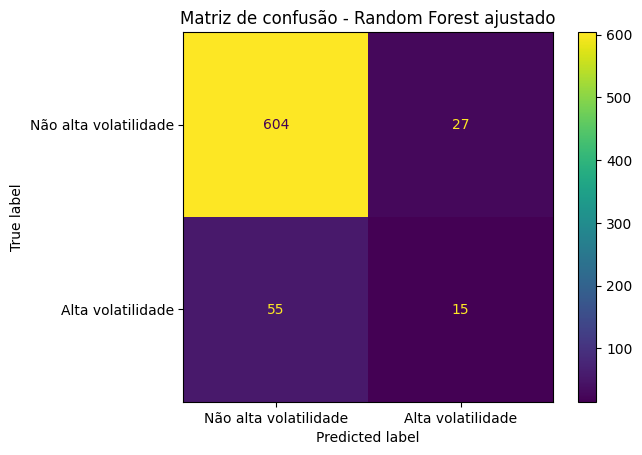

In [21]:
# Matriz de confusão do modelo final
gerar_matriz_confusao(
	y_test,
	y_pred_final,
	"Matriz de confusão - Random Forest ajustado"
)

In [22]:
# Comparação entre baseline e modelo final
comparacao_final = results_df[
	results_df["modelo"].isin(["Dummy Classifier", "Random Forest", "Random Forest ajustado"])
].sort_values("f1", ascending=False)

comparacao_final

,modelo,accuracy,precision,recall,f1,roc_auc,train_time_s
6,Random Forest ajustado,0.883024,0.357143,0.214286,0.267857,0.577994,4.566
3,Random Forest,0.888730,0.382353,0.185714,0.250000,0.577994,4.566
0,Dummy Classifier,0.900143,0.000000,0.000000,0.000000,0.500000,0.065


## 10.1 Análise de erros e limitações

**Resposta:**
A análise dos resultados indica que o modelo final ainda apresenta dificuldade para identificar todos os períodos futuros de alta volatilidade. O principal tipo de erro observado são os falsos negativos, ou seja, situações em que o período seguinte apresentou alta volatilidade, mas o modelo classificou como não alta volatilidade. Esse tipo de erro é relevante para o problema, pois significa que o modelo deixa de sinalizar alguns períodos de maior instabilidade.

Também existem falsos positivos, isto é, casos em que o modelo indicou alta volatilidade futura, mas o período seguinte não foi classificado dessa forma. Isso mostra que, mesmo quando o modelo gera um alerta, ele ainda possui incerteza considerável. Portanto, as previsões não devem ser interpretadas como sinais confiáveis para tomada de decisão financeira.

Não há evidência clara de overfitting forte, pois a avaliação foi feita em um conjunto de teste posterior ao período de treinamento, respeitando a ordem temporal dos dados. No entanto, o desempenho limitado sugere possível underfitting ou, mais provavelmente, que as variáveis utilizadas não capturam toda a complexidade do fenômeno. A volatilidade do Bitcoin pode ser influenciada por fatores externos que não estão presentes na base, como notícias, eventos regulatórios, condições macroeconômicas, liquidez global e sentimento de mercado.

A métrica principal escolhida, o F1-score da classe positiva, é adequada porque o objetivo do MVP é identificar períodos de alta volatilidade, e não apenas maximizar a acurácia geral. A acurácia pode ser enganosa neste problema, já que a classe negativa é mais frequente e um modelo que prevê majoritariamente essa classe pode parecer bom sem cumprir o objetivo principal.

A principal limitação dos dados é que eles incluem apenas informações históricas de mercado do par BTCUSDT. Além disso, o desempenho pode variar em diferentes regimes de mercado, o que representa risco de generalização. Um modelo treinado em um período específico pode não se comportar da mesma forma em cenários futuros com características muito diferentes.

Por essas razões, o modelo não deveria ser usado para recomendação de investimento, decisão de compra ou venda, gestão automatizada de risco ou qualquer aplicação financeira real sem validações adicionais. Ele deve ser interpretado como um experimento acadêmico de classificação, útil para avaliar a possibilidade de antecipar regimes de maior volatilidade a partir de dados históricos, mas ainda insuficiente como ferramenta operacional confiável.



# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Classificador Dummy | F1 = 0.0000 | Acurácia = 0.9001; Precisão = 0.0000; Revocação = 0.0000; ROC-AUC = 0.5000 | obtido no notebook | Baseline; prevê sempre a classe majoritária e não identifica alta volatilidade |
| Regressão Logística | F1 = 0.0000 | Acurácia = 0.8973; Precisão = 0.0000; Revocação = 0.0000; ROC-AUC = 0.6254 | obtido no notebook | Modelo linear; apresentou ROC-AUC acima do baseline, mas não classificou positivos no limiar padrão |
| Árvore de Decisão | F1 = 0.2112 | Acurácia = 0.2539; Precisão = 0.1180; Revocação = 1.0000; ROC-AUC = 0.5578 | obtido no notebook | Identificou todos os positivos, mas gerou muitos falsos positivos |
| Floresta Aleatória | F1 = 0.2500 | Acurácia = 0.8887; Precisão = 0.3824; Revocação = 0.1857; ROC-AUC = 0.5780 | obtido no notebook | Melhor equilíbrio inicial entre precisão e revocação |
| SVM | F1 = 0.0937 | Acurácia = 0.4479; Precisão = 0.0560; Revocação = 0.2857; ROC-AUC = 0.2895 | obtido no notebook | Teve desempenho baixo e muitos erros de classificação |
| Floresta Aleatória ajustada | F1 = 0.2679 | Acurácia = 0.8830; Precisão = 0.3571; Revocação = 0.2143; ROC-AUC = 0.5780 | obtido no notebook | Melhor modelo final por F1-score; escolhido por detectar parte da classe positiva |


# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar `RANDOM_STATE = 42` | Garantir maior reprodutibilidade nos modelos com componentes aleatórios | Permitir que os resultados sejam reproduzidos em novas execuções do notebook |
| Usar dados públicos da Binance Public Data | Garantir que o notebook possa ser executado sem credenciais, APIs privadas ou upload manual | Aumentar a reprodutibilidade e evitar problemas de confidencialidade |
| Formular o problema como classificação binária | A variável-alvo indica apenas duas classes: alta volatilidade futura ou não alta volatilidade futura | Permitir o uso de modelos supervisionados de classificação |
| Usar divisão temporal entre treino e teste | Os dados representam uma série histórica diária, portanto não devem ser embaralhados aleatoriamente | Simular uma situação real em que o modelo aprende com o passado e é avaliado no futuro |
| Remover `date` das features | A coluna de data foi usada apenas para ordenação temporal e separação treino/teste | Evitar que o modelo use a data diretamente como variável explicativa |
| Remover `future_volatility_30d` das features | Essa coluna contém informação dos 30 dias seguintes e causaria vazamento de dados | Evitar desempenho artificial e preservar a validade da avaliação |
| Usar F1-score como métrica principal | A classe positiva é menos frequente e o objetivo é identificar períodos de alta volatilidade | Avaliar melhor o equilíbrio entre precisão e revocação da classe positiva |
| Usar `DummyClassifier` como baseline | A base é desbalanceada e um modelo simples pode obter acurácia alta prevendo a classe majoritária | Verificar se os modelos realmente aprendem algo além da classe mais frequente |
| Testar Regressão Logística | Modelo linear simples e interpretável | Servir como referência inicial entre os modelos candidatos |
| Testar Árvore de Decisão | Modelo capaz de capturar relações não lineares de forma simples | Avaliar uma abordagem baseada em regras de decisão |
| Testar Random Forest | Modelo de ensemble capaz de combinar várias árvores de decisão | Melhorar a robustez e capturar relações não lineares entre variáveis |
| Testar SVM | Modelo baseado em margem, com comportamento diferente dos modelos de árvore | Comparar uma abordagem alternativa para classificação |
| Usar padronização em Regressão Logística e SVM | Esses modelos são sensíveis à escala das variáveis | Evitar que variáveis com escala maior dominem o treinamento |
| Não aplicar padronização em modelos de árvore | Decision Tree e Random Forest não dependem da escala das variáveis | Simplificar o pipeline desses modelos sem prejudicar o desempenho |
| Usar `class_weight="balanced"` | A variável-alvo apresenta desbalanceamento entre as classes | Reduzir o viés dos modelos em favor da classe majoritária |
| Realizar busca simples de hiperparâmetros no Random Forest | O Random Forest teve bom desempenho inicial e era o principal candidato a modelo final | Verificar se ajustes simples poderiam melhorar o resultado |
| Usar `TimeSeriesSplit` na otimização | A validação deve respeitar a ordem temporal dos dados | Reduzir risco de vazamento temporal durante a busca de hiperparâmetros |
| Ajustar o limiar de decisão do Random Forest | O limiar padrão de 0,5 pode ser conservador em problemas desbalanceados | Melhorar o equilíbrio entre precisão, revocação e F1-score |
| Limitar a busca de hiperparâmetros | O objetivo é um MVP acadêmico, não uma otimização exaustiva | Manter o projeto simples, compreensível e computacionalmente leve |
| Executar os modelos em CPU | O dataset é pequeno e os modelos são relativamente leves | Evitar dependência de GPU e facilitar a reprodução do notebook |
| Não usar dados internos do LiveCoinWatch | O LiveCoinWatch foi usado apenas como motivação profissional do tema | Evitar problemas de confidencialidade, autorização ou propriedade dos dados |
| Não usar o modelo para recomendação financeira | O desempenho foi limitado e o modelo não prevê direção do preço | Evitar interpretações indevidas e reforçar o caráter acadêmico do MVP |

# 13. Conclusão

Este MVP teve como objetivo construir e avaliar modelos de Machine Learning para classificar períodos futuros de alta volatilidade do Bitcoin, utilizando dados históricos públicos do par BTCUSDT. O problema foi formulado como uma tarefa de classificação binária supervisionada, em que a classe positiva representa períodos em que os 30 dias seguintes apresentaram alta volatilidade.

A melhor solução encontrada foi o modelo de Random Forest ajustado, escolhido por apresentar o melhor F1-score para a classe positiva. Embora o baseline tenha alcançado acurácia elevada, ele não identificou nenhum caso de alta volatilidade, pois previa sempre a classe majoritária. Por isso, o Random Forest ajustado foi considerado mais adequado ao objetivo do projeto, já que conseguiu detectar parte dos períodos positivos.

Os resultados mostram que a previsão de alta volatilidade futura é uma tarefa difícil. O desempenho do modelo foi limitado, indicando que os dados históricos de preço, volume, número de negociações, médias móveis e volatilidade passada possuem algum sinal útil, mas não suficiente para produzir uma classificação robusta fora da amostra. Esse resultado é coerente com a natureza do problema, pois mercados financeiros e criptoativos são influenciados por fatores externos que não estão presentes na base utilizada.

O principal aprendizado do projeto foi que a acurácia isolada pode ser enganosa em problemas com classes desbalanceadas. Nesse contexto, métricas como precision, recall e F1-score são mais adequadas para avaliar se o modelo realmente consegue identificar a classe de interesse. Também ficou evidente a importância de evitar vazamento de dados, respeitar a ordem temporal da série e comparar os modelos com um baseline simples.

Como limitações, o projeto utilizou apenas dados históricos de mercado, sem incluir notícias, indicadores macroeconômicos, sentimento de mercado, eventos regulatórios ou outras variáveis externas que podem influenciar a volatilidade do Bitcoin. Além disso, o ajuste de hiperparâmetros foi simples, compatível com o escopo de um MVP acadêmico, mas ainda distante de uma otimização completa.

Como próximos passos, poderiam ser testadas novas variáveis explicativas, diferentes horizontes de previsão, validação temporal com janelas móveis, outros modelos de classificação e fontes externas de informação. O modelo também poderia ser avaliado em outros períodos de mercado para verificar sua capacidade de generalização. Ainda assim, o MVP cumpriu seu objetivo ao construir um pipeline completo de Machine Learning e avaliar, de forma crítica, a viabilidade de antecipar períodos de maior volatilidade do Bitcoin.

# 14. Salvamento de artefatos

Nesta etapa salvaremos alguns artefatos gerados durante o MVP, como a tabela de resultados dos modelos e, opcionalmente, o modelo final treinado. Como o dataset é pequeno e os modelos têm baixo custo computacional, o salvamento do modelo não é obrigatório para a execução do notebook.


In [23]:
# === Salvamento de artefatos ===
# Salva a tabela de comparação dos modelos em CSV.

results_df.to_csv("resultados_modelos_bitcoin.csv", index=False)

print("Tabela de resultados salva como resultados_modelos_bitcoin.csv")

# Salvamento do modelo final treinado

modelo_final = trained_models["Random Forest"]

joblib.dump(modelo_final, "modelo_final_random_forest.pkl")

print("Modelo final salvo como modelo_final_random_forest.pkl")


Tabela de resultados salva como resultados_modelos_bitcoin.csv
Modelo final salvo como modelo_final_random_forest.pkl
